# Baseline model training and evaluation

Set up some baseline comparison methods to perform next-frame prediction on the sample of 200 replays. 

In [16]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from impulse.collection.database import ImpulseDB
from impulse.collection.s3_manager import S3Manager
from impulse.replay_dataset import ReplayDataset
from impulse.preprocessing import SegmentedDataset

load_dotenv()

True

In [17]:
impulse_path = os.getenv('IMPULSE_PATH')
db_path = os.getenv('DB_PATH')
project_root = os.getenv('PROJECT_ROOT')

db = ImpulseDB(db_path)
s3 = S3Manager()

Database initialized: /Users/david/dev/impulse/impulse.db
✓ S3 Manager initialized (Local Credentials)
  Region: us-east-2
  Bucket: impulse-rl-4e8e-a163-3a3b24a95b2b


In [3]:
cache_dir = project_root+'replay-cache/'
dataset = ReplayDataset(
    db_path = db_path,
    s3_manager = s3,
    cache_dir=cache_dir
)

replay_list = dataset.load_sample(200, seed=51)

Found 7282 parsed replays in database
Loaded 200/200 replays


In [4]:
physics_boost_cols = [
    'Ball - position x',
    'Ball - position y',
    'Ball - position z',
    'Ball - linear velocity x',
    'Ball - linear velocity y',
    'Ball - linear velocity z',
    'Ball - angular velocity x',
    'Ball - angular velocity y',
    'Ball - angular velocity z',
    'Ball - quaternion x',
    'Ball - quaternion y',
    'Ball - quaternion z',
    'Ball - quaternion w',

    'p0_position x',
    'p0_position y',
    'p0_position z',
    'p0_linear velocity x',
    'p0_linear velocity y',
    'p0_linear velocity z',
    'p0_angular velocity x',
    'p0_angular velocity y',
    'p0_angular velocity z',
    'p0_quaternion x',
    'p0_quaternion y',
    'p0_quaternion z',
    'p0_quaternion w',
    'p0_boost level',

    'p1_position x',
    'p1_position y',
    'p1_position z',
    'p1_linear velocity x',
    'p1_linear velocity y',
    'p1_linear velocity z',
    'p1_angular velocity x',
    'p1_angular velocity y',
    'p1_angular velocity z',
    'p1_quaternion x',
    'p1_quaternion y',
    'p1_quaternion z',
    'p1_quaternion w',
    'p1_boost level',

    'p2_position x',
    'p2_position y',
    'p2_position z',
    'p2_linear velocity x',
    'p2_linear velocity y',
    'p2_linear velocity z',
    'p2_angular velocity x',
    'p2_angular velocity y',
    'p2_angular velocity z',
    'p2_quaternion x',
    'p2_quaternion y',
    'p2_quaternion z',
    'p2_quaternion w',
    'p2_boost level',

    'p3_position x',
    'p3_position y',
    'p3_position z',
    'p3_linear velocity x',
    'p3_linear velocity y',
    'p3_linear velocity z',
    'p3_angular velocity x',
    'p3_angular velocity y',
    'p3_angular velocity z',
    'p3_quaternion x',
    'p3_quaternion y',
    'p3_quaternion z',
    'p3_quaternion w',
    'p3_boost level',

    'p4_position x',
    'p4_position y',
    'p4_position z',
    'p4_linear velocity x',
    'p4_linear velocity y',
    'p4_linear velocity z',
    'p4_angular velocity x',
    'p4_angular velocity y',
    'p4_angular velocity z',
    'p4_quaternion x',
    'p4_quaternion y',
    'p4_quaternion z',
    'p4_quaternion w',
    'p4_boost level',
    
    'p5_position x',
    'p5_position y',
    'p5_position z',
    'p5_linear velocity x',
    'p5_linear velocity y',
    'p5_linear velocity z',
    'p5_angular velocity x',
    'p5_angular velocity y',
    'p5_angular velocity z',
    'p5_quaternion x',
    'p5_quaternion y',
    'p5_quaternion z',
    'p5_quaternion w',
    'p5_boost level',    
]

all_cols = replay_list[0].frames.columns

In [5]:
all_cols_set = set(all_cols)
physics_boost_cols_set = set(physics_boost_cols)
cols_to_drop = list(all_cols_set - physics_boost_cols_set)
cols_to_drop.sort()
cols_to_drop

['current time',
 'frame',
 'frame time',
 'p0_dodge active',
 'p0_double jump active',
 'p0_jump active',
 'p0_player demolished by',
 'p1_dodge active',
 'p1_double jump active',
 'p1_jump active',
 'p1_player demolished by',
 'p2_dodge active',
 'p2_double jump active',
 'p2_jump active',
 'p2_player demolished by',
 'p3_dodge active',
 'p3_double jump active',
 'p3_jump active',
 'p3_player demolished by',
 'p4_dodge active',
 'p4_double jump active',
 'p4_jump active',
 'p4_player demolished by',
 'p5_dodge active',
 'p5_double jump active',
 'p5_jump active',
 'p5_player demolished by',
 'seconds remaining']

In [6]:
replay_list_dropped_cols = replay_list.copy()

for replay in replay_list_dropped_cols:
    replay.frames.drop(columns=cols_to_drop, inplace=True)

replay_list_dropped_cols[0].frames.columns

Index(['Ball - position x', 'Ball - position y', 'Ball - position z',
       'Ball - linear velocity x', 'Ball - linear velocity y',
       'Ball - linear velocity z', 'Ball - angular velocity x',
       'Ball - angular velocity y', 'Ball - angular velocity z',
       'Ball - quaternion x', 'Ball - quaternion y', 'Ball - quaternion z',
       'Ball - quaternion w', 'p0_position x', 'p0_position y',
       'p0_position z', 'p0_linear velocity x', 'p0_linear velocity y',
       'p0_linear velocity z', 'p0_angular velocity x',
       'p0_angular velocity y', 'p0_angular velocity z', 'p0_quaternion x',
       'p0_quaternion y', 'p0_quaternion z', 'p0_quaternion w',
       'p0_boost level', 'p1_position x', 'p1_position y', 'p1_position z',
       'p1_linear velocity x', 'p1_linear velocity y', 'p1_linear velocity z',
       'p1_angular velocity x', 'p1_angular velocity y',
       'p1_angular velocity z', 'p1_quaternion x', 'p1_quaternion y',
       'p1_quaternion z', 'p1_quaternion w', 'p1

In [7]:
replay_list_dropped_cols[0].frames.shape

(9394, 97)

In [8]:
BOUNDS = {
    'position x' :                  4096,   # [-1,1]
    'position y' :                  5120,   # [-1,1]
    'position z' :                  2044,   # [-1,1]
    'ball max speed' :              6000,   # [-1,1] for lin vel features
    'ball max angular speed' :      6,      # [-1,1] for ang vel features
    'player max speed' :            2300,   # [-1,1] for lin vel features
    'player max angular speed' :    5.5,    # [-1,1] for ang vel features
    'max boost' :                   255     # [0,1]
}

In [9]:
pos_x_cols = [col for col in physics_boost_cols if 'position x' in col]
pos_y_cols = [col for col in physics_boost_cols if 'position y' in col]
pos_z_cols = [col for col in physics_boost_cols if 'position z' in col]

lin_vel_cols = [col for col in physics_boost_cols if 'linear velocity' in col]
ball_lin_vel_cols = [col for col in lin_vel_cols if 'Ball' in col]
player_lin_vel_cols = [col for col in lin_vel_cols if 'p' in col]

ang_vel_cols = [col for col in physics_boost_cols if 'angular velocity' in col]
ball_ang_vel_cols = [col for col in ang_vel_cols if 'Ball' in col]
player_ang_vel_cols = [col for col in ang_vel_cols if 'p' in col]

boost_cols = [col for col in physics_boost_cols if 'boost' in col]

In [10]:
def normalize_features(df):

    # Position features
    df[pos_x_cols] /= BOUNDS['position x']
    df[pos_y_cols] /= BOUNDS['position y']
    df[pos_z_cols] /= BOUNDS['position z']

    # Linear velocity features
    df[ball_lin_vel_cols] /= BOUNDS['ball max speed']
    df[player_lin_vel_cols] /= BOUNDS['player max speed']

    # Angular velocity features
    df[ball_ang_vel_cols] /= BOUNDS['ball max angular speed']
    df[player_ang_vel_cols] /= BOUNDS['player max angular speed']

    # Boost 
    df[boost_cols] /= BOUNDS['max boost']

In [24]:
# Build SegmentedDataset from the pre-loaded replay list
seg_dataset = SegmentedDataset.from_replay_list(replay_list_dropped_cols)
segments = seg_dataset.all_segments_list()

for seg in segments:
    normalize_features(seg.frames)

frame_lens = [len(s) for s in segments]
total_frames = sum(frame_lens)
print(f"Replays:      {len(replay_list_dropped_cols)}")
print(f"Segments:     {len(segments)}")
print(f"Total frames: {total_frames:,}")
print("\nFrame lengths stats:\n", pd.Series(frame_lens).describe())

Replays:      200
Segments:     1069
Total frames: 1,936,103

Frame lengths stats:
 count     1069.000000
mean      1811.134705
std       1756.025797
min         10.000000
25%        587.000000
50%       1227.000000
75%       2536.000000
max      16872.000000
dtype: float64


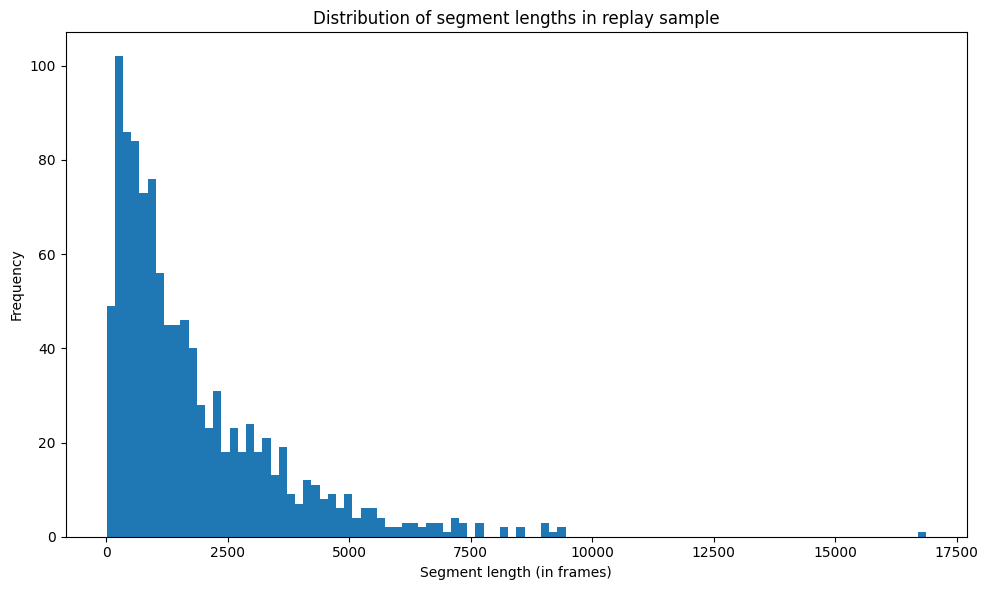

In [25]:
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(frame_lens, bins=100)
ax.set_xlabel("Segment length (in frames)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of segment lengths in replay sample")
fig.tight_layout()
plt.show()

## Naive method

In [ ]:
feature_cols = segments[0].frames.columns.tolist()

sum_sq = np.zeros(len(feature_cols), dtype=np.float64)
n_pairs = 0

for seg in segments:
    arr = seg.frames.values  
    if len(arr) < 2:
        continue
    diff = arr[:-1] - arr[1:]            # within-segment consecutive-frame differences
    sum_sq += (diff ** 2).sum(axis=0)    # accumulate squared errors per feature
    n_pairs += len(diff)

feature_wise_mse = pd.Series(sum_sq / n_pairs, index=feature_cols)
print(f"Frame pairs evaluated: {n_pairs:,} across {len(segments)} segments")

Frame pairs evaluated: 1,935,034 across 1069 segments


In [13]:
feature_wise_mse

Ball - position x           0.000109
Ball - position y           0.000109
Ball - position z           0.000121
Ball - linear velocity x    0.001840
Ball - linear velocity y    0.002837
                              ...   
p5_quaternion x             0.011804
p5_quaternion y             0.013519
p5_quaternion z             0.023683
p5_quaternion w             0.023656
p5_boost level              0.001730
Length: 97, dtype: float64

In [14]:
feature_wise_mse_sorted = feature_wise_mse.sort_values(ascending=False)
feature_wise_mse_sorted

Ball - angular velocity z    141.985530
Ball - angular velocity x    129.175023
p5_angular velocity x        100.541593
p2_angular velocity x        100.279622
p3_angular velocity x        100.145777
                                ...    
p0_position z                  0.000069
p5_position z                  0.000068
p3_position z                  0.000068
p2_position z                  0.000068
p4_position z                  0.000067
Length: 97, dtype: float64

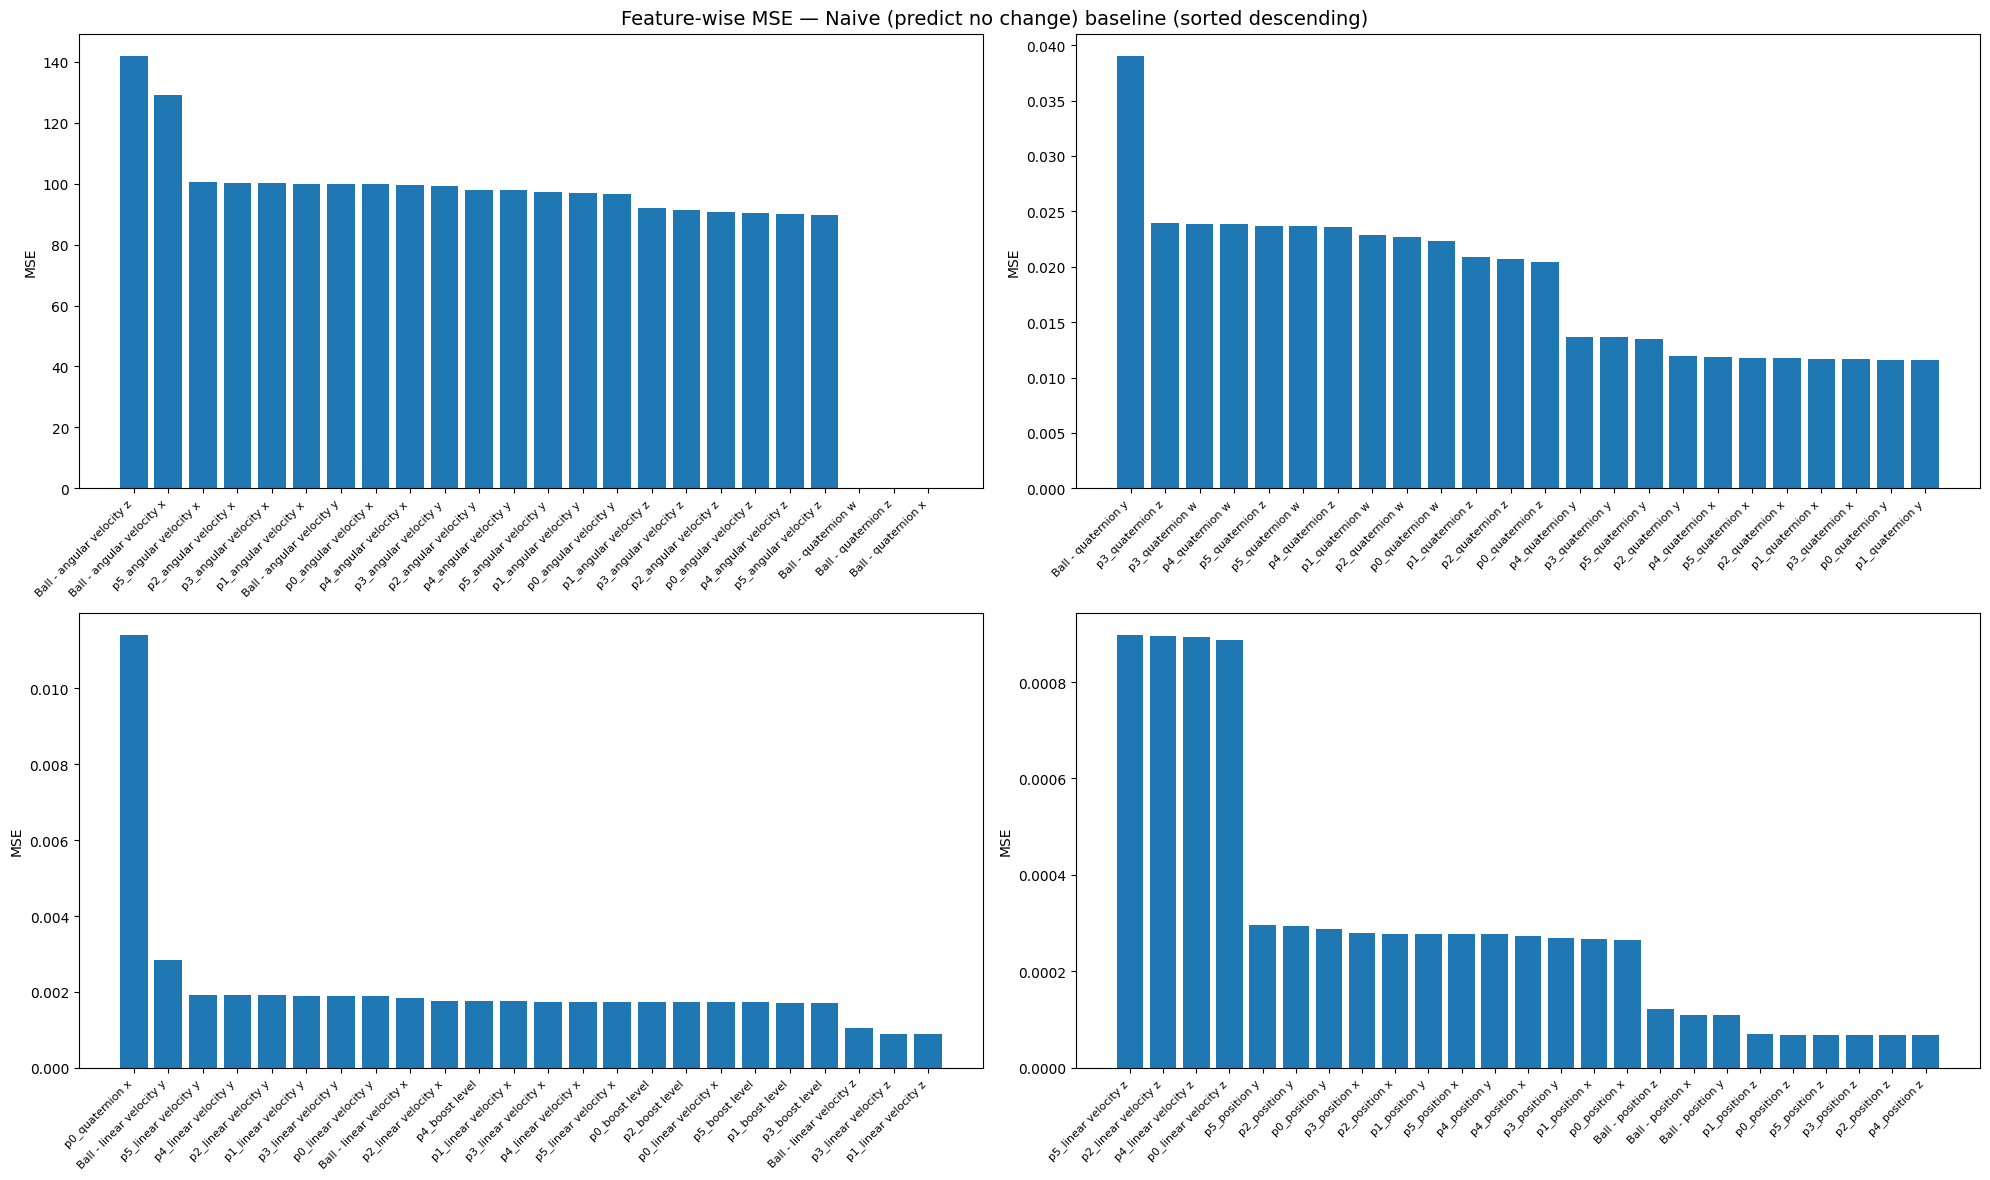

In [15]:
cols = feature_wise_mse_sorted.index.tolist()
values = feature_wise_mse_sorted.values
chunk_sizes = [24, 24, 24, 25]
chunks = []
start = 0
for size in chunk_sizes:
    chunks.append((cols[start:start+size], values[start:start+size]))
    start += size

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
for ax, (chunk_cols, chunk_vals) in zip(axes.flat, chunks):
    ax.bar(chunk_cols, chunk_vals)
    ax.set_xticks(range(len(chunk_cols)))
    ax.set_xticklabels(chunk_cols, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('MSE')

fig.suptitle('Feature-wise MSE — Naive (predict no change) baseline (sorted descending)', fontsize=14)
plt.tight_layout()
plt.show()